# Basics of Regression Methods

# Objectives

* Practice loading data from CSV files and manipulating that data with Pandas and NumPy
* Try out sklearn's linear regression on a dataset with 1-dim. features and many features
* Try out sklearn's k-nearest neighbor regression on a dataset with 1-dim. features and many features
* Try out comparing models using mean squared error as a performance metric

# What to do

Download the *abalone* dataset from our course starter-code repo here:

* Dataset CSV files: https://github.com/tufts-ml-courses/cs135-26s-assignments/tree/main/labs/data_abalone
* Dataset README: https://github.com/tufts-ml-courses/cs135-26s-assignments/tree/main/labs/data_abalone/README.md

In class (or later at home), work your way through this notebook. 

Each "part" has a structure like this:

* First, some prefilled content so you can learn how to do basic ML operations with sklearn.
* Second, some simple exercises to try to figure things out yourself


# Outline

* [Part 1: Linear Regression with 1-dim. features](#part1)
* * Real Task: Regression of 'rings' given 'length' using abalone dataset
* * Exercise 1a: Reproduce the `predict` method
* [Part 2: Linear Regression with 3-dim. features](#part2)
* * Real Task: Regression of 'rings' given 'length', 'height', 'weight'
* * Exercise 2a: Reproduce the `predict` method
* * Exercise 2b: Compare mean squared error on training set with model from part 1
* [Part 3: K-nearest neighbor regression](#part3)
* * Real Task: Regression of 'rings' given 'length'
* * Exercise 3a: How does training set error vary with number of neighbors?
* * Exercise 3b: Repeat using all available features (not just length)
* * Exercise 3c: Reproduce the `predict` method for k-NN


# Import libraries

In [159]:
%pip install scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [160]:
import numpy as np
import pandas as pd
import os

In [161]:
import sklearn

In [162]:
# import plotting libraries
import matplotlib
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

import seaborn as sns
sns.set_theme('notebook', style='whitegrid', font_scale=1.25)

In [163]:
os.getcwd()

'/Users/brianwang/Downloads/ml_learning/Tufts_CS135_23/Regression'

# Part 1: Simple Linear Regression with 1-dim. features



### Goal: Predict 'rings' outcome given 'length' of abalone

We'll do this in a few easy steps below:

1) Load in 'x' training data, the 'length' of each abalone

2) Load in 'y' training data, the 'rings' count of each abalone

3) Train a linear regression model by calling 'fit'

4) Make predictions using this model by calling 'predict'

### Step 1: Load in 'x', the inputs for our regression task

In [164]:
# Show the first 5 lines of this CSV:

with open('data_abalone/x_train.csv', 'r') as f:
    for line in f.readlines()[:5]:
        print(line.strip())

is_male,length_mm,diam_mm,height_mm,whole_weight_g,shucked_weight_g,viscera_weight_g,shell_weight_g
0.0,0.43,0.325,0.09,0.425,0.217,0.087,0.095
0.0,0.575,0.445,0.135,0.883,0.381,0.2035,0.26
0.0,0.585,0.475,0.185,0.8575,0.3465,0.1785,0.275
0.0,0.48,0.35,0.1,0.519,0.2365,0.1275,0.126


In [165]:
# Load in the data into a Panda's dataframe called 'x_df'
x_df = pd.read_csv('data_abalone/x_train.csv')

In [166]:
# Show first 3 rows
x_df.head(3)

,is_male,length_mm,diam_mm,height_mm,whole_weight_g,shucked_weight_g,viscera_weight_g,shell_weight_g
0,0.0,0.430,0.325,0.090,0.4250,0.2170,0.0870,0.095
1,0.0,0.575,0.445,0.135,0.8830,0.3810,0.2035,0.260
2,0.0,0.585,0.475,0.185,0.8575,0.3465,0.1785,0.275


In [167]:
# Print summary stats
x_df.describe()

,is_male,length_mm,diam_mm,height_mm,whole_weight_g,shucked_weight_g,viscera_weight_g,shell_weight_g
count,3176.000000,3176.000000,3176.000000,3176.000000,3176.000000,3176.000000,3176.000000,3176.000000
mean,0.360516,0.523352,0.407434,0.139406,0.824952,0.358798,0.179893,0.237566
std,0.480226,0.119343,0.098652,0.042651,0.487228,0.221327,0.109260,0.138865
min,0.000000,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500
25%,0.000000,0.450000,0.350000,0.115000,0.442875,0.186500,0.093000,0.130000
50%,0.000000,0.545000,0.425000,0.140000,0.800250,0.335500,0.170000,0.229500
75%,1.000000,0.615000,0.480000,0.165000,1.146625,0.498500,0.248500,0.326125
max,1.000000,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000


In [168]:
# Show how to access column names
for col in x_df.columns:
    print(col)

is_male
length_mm
diam_mm
height_mm
whole_weight_g
shucked_weight_g
viscera_weight_g
shell_weight_g


In [169]:
# Convert from pandas DataFrame to a numpy array with N rows and F columns
x_NF = x_df.values.copy()

print(type(x_NF))

<class 'numpy.ndarray'>


In [170]:
print(x_NF.shape)

(3176, 8)


In [171]:
print(x_NF.dtype)

float64


In [172]:
# Convert only the 'length' column into a numpy array

xlength_N1 = x_df.loc[:, ['length_mm']].values.copy()

print(xlength_N1.shape)

(3176, 1)


OK, now we've got our input! Time for step 2....

### Step 2: Load in 'y', the output of our regression task

In [173]:
y_df = pd.read_csv('data_abalone/y_train.csv')

In [174]:
# Show first 6 rows
y_df.head(6)

,rings
0,7
1,11
2,12
3,7
4,11
5,4


In [175]:
# Print summary stats
y_df.describe()

,rings
count,3176.000000
mean,9.902393
std,3.205887
min,1.000000
25%,8.000000
50%,9.000000
75%,11.000000
max,29.000000


In [176]:
y_N1 = y_df.loc[:, ['rings']].values.copy()

In [177]:
y_N1.shape

(3176, 1)

### Step 3: Fit a linear regression model, using sklearn

In [178]:
import sklearn.linear_model

In [179]:
# Construct the regression "object"
# The variable 'lin_regr' here is an "instance" of the LinearRegression class

lin_regr = sklearn.linear_model.LinearRegression()

See the documentation:

<https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression>


Any constructed regressor in sklearn (like 'lin_regr') has two useful methods:
* 'fit' method
* 'predict' method (only works after 'fit' is called)

The 'fit' method will *TRAIN* the model

Practically, this method call will 

1) Estimate weight coefficients $w$ and bias/intercept $b$ to minimize mean squared error

2) Updates internal state of the object with these estimated values.

For linear regression specifically:

* an attribute called `coef_` holds the weights
* an attribute called `intercept_` holds the intercept value

In [180]:
lin_regr.fit(xlength_N1, y_N1);

What changed after calling fit?

The *internal state* of the object was updated.

We can see the *internal state* via the "coef" attribute (the *slope* parameter) and the "intercept" attribute (aka *bias* parameter)

In [181]:
lin_regr.coef_

array([[14.77184885]])

In [182]:
lin_regr.intercept_

array([2.17152073])

How would you know what an object can do??

Pro tip: in an active Jupyter notebook, you can use *tab completion* to interactively inspect an object

Just type "lin_regr." and then press the <tab> key.
    
You should see a pop up menu that let's you see what methods and attributes are accessible, like this:
    
![Image of tab completion](https://www.cs.tufts.edu/comp/135/2020f/images/day02_jupyter_object_inspect_on_tab.png)

### Step 4: Make predictions using this trained linear regression model

In [183]:
# Prepare to evaluate predictions at several possible length values:
G = 7
x_grid_G = np.asarray([0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5])
print(x_grid_G)

[0.   0.25 0.5  0.75 1.   1.25 1.5 ]


In [184]:
# Turn this into a G x 1 2-dim array, since sklearn *always* expects feature input to be 2-dim
x_grid_G1 = x_grid_G[:,np.newaxis]

Now, we call `predict`, which, when given 2-dim array with shape (G,F) of features, will return a 2-dim array of size (G, 1) of *predicted values*

In [185]:
yhat_lin_G1 = lin_regr.predict(x_grid_G1)
print(yhat_lin_G1)
print(yhat_lin_G1.shape)

[[ 2.17152073]
 [ 5.86448295]
 [ 9.55744516]
 [13.25040737]
 [16.94336959]
 [20.6363318 ]
 [24.32929401]]
(7, 1)


### Step 5: Plot the *predicted* values side by side with the observed training data

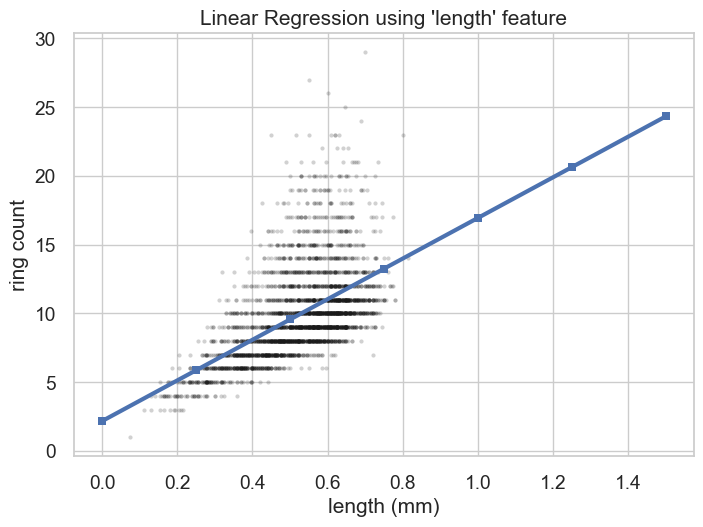

In [186]:
plt.plot(xlength_N1, y_N1, 'k.', alpha=0.2) # k. means black dots without a connecting line
plt.plot(x_grid_G, yhat_lin_G1, 'bs-', linewidth=3);
plt.xlabel('length (mm)'); plt.ylabel('ring count');
plt.title("Linear Regression using 'length' feature");

### Step 6: Calculate the mean squared error on the observed training data
 

In [187]:
yhat_train_N1 = lin_regr.predict(xlength_N1)
sklearn.metrics.mean_squared_error(y_N1, yhat_train_N1)

7.167580293483765

# Part 2: Linear Regression with multiple features

### Goal: Predict 'rings' outcome given 'length', 'height', and 'weight' of abalone

How would we do if we wanted to predict 'rings' given not just length, but also height and weight?

### Prepare the data

We now want our features array to have shape: (n_examples, 3)

Since 3 would let us use length and height and weight

In [188]:
for col in x_df.columns:
    print(col)

is_male
length_mm
diam_mm
height_mm
whole_weight_g
shucked_weight_g
viscera_weight_g
shell_weight_g


In [189]:
# Grab relevant columns only, convert to a numeric array
x_N3 = x_df.loc[:, ['length_mm', 'height_mm', 'whole_weight_g']].values.copy()
print(type(x_N3))
print(x_N3.dtype)
print(x_N3.shape)

<class 'numpy.ndarray'>
float64
(3176, 3)


#### Construct the model as an sklearn regressor object

In [190]:
lin_regr_3dim = sklearn.linear_model.LinearRegression()

#### Fit the model

In [191]:
lin_regr_3dim.fit(x_N3, y_N1)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [192]:
# TODO: what are the learned weights?
lin_regr_3dim.coef_

array([[ 7.0627805 , 19.64482851,  0.53907213]])

In [193]:
# TODO: what is the learned intercept?
lin_regr_3dim.intercept_

array([3.02274963])

# Part 3: K-nearest Neighbor Regression with 1-dim features

### Goal: Try out sklearn's built-in nearest neighbor regressor



In [194]:
import sklearn.neighbors

In [195]:
k1nn_regr = sklearn.neighbors.KNeighborsRegressor(n_neighbors=1)

In [196]:
# Fit the model
k1nn_regr.fit(xlength_N1, y_N1);

In [197]:
# Prepare to evaluate predictions at several possible length values:
G = 21
x_grid_G = np.linspace(0, 1.5, G)
print(x_grid_G)

[0.    0.075 0.15  0.225 0.3   0.375 0.45  0.525 0.6   0.675 0.75  0.825
 0.9   0.975 1.05  1.125 1.2   1.275 1.35  1.425 1.5  ]


In [198]:
x_grid_G1 = np.reshape(x_grid_G, (G, 1))
print(x_grid_G1)

[[0.   ]
 [0.075]
 [0.15 ]
 [0.225]
 [0.3  ]
 [0.375]
 [0.45 ]
 [0.525]
 [0.6  ]
 [0.675]
 [0.75 ]
 [0.825]
 [0.9  ]
 [0.975]
 [1.05 ]
 [1.125]
 [1.2  ]
 [1.275]
 [1.35 ]
 [1.425]
 [1.5  ]]


In [199]:
# Make predictions on the same grid of x input values
yhat_k1nn_G1 = k1nn_regr.predict(x_grid_G1)

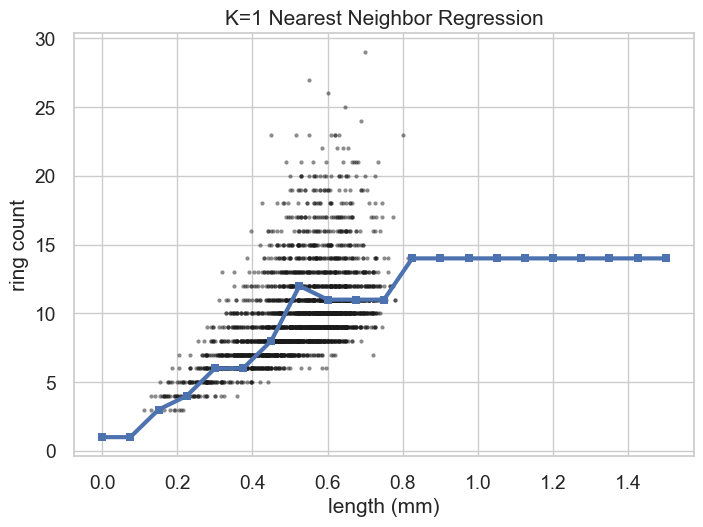

In [200]:
plt.plot(xlength_N1, y_N1, 'k.', alpha=0.5)
plt.plot(x_grid_G, yhat_k1nn_G1, 'bs-', linewidth=3);
plt.xlabel('length (mm)'); plt.ylabel('ring count');
plt.title('K=1 Nearest Neighbor Regression');

#### Retry with 5 nearest neighbors

In [201]:
k5nn_regr = sklearn.neighbors.KNeighborsRegressor(
    n_neighbors=5, algorithm='brute', metric='euclidean')

In [202]:
# Fit the model
k5nn_regr.fit(xlength_N1, y_N1);

In [203]:
# Make predictions on the same grid of x input values
yhat_k5nn_G1 = k5nn_regr.predict(x_grid_G1)

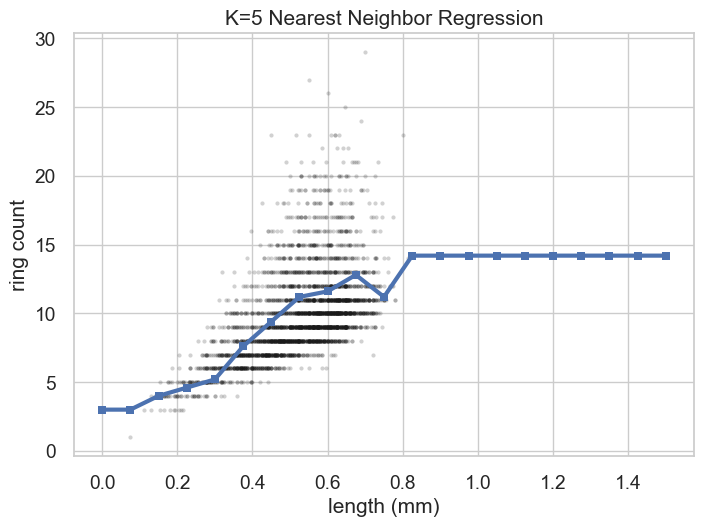

In [204]:
plt.plot(xlength_N1, y_N1, 'k.', alpha=0.2)
plt.plot(x_grid_G1, yhat_k5nn_G1, 'bs-', linewidth=3);
plt.xlabel('length (mm)'); plt.ylabel('ring count');
plt.title('K=5 Nearest Neighbor Regression');

### Retry with 100 nearest neighbors

In [205]:
k100nn_regr = sklearn.neighbors.KNeighborsRegressor(
    n_neighbors=100, algorithm='brute', metric='euclidean')

In [206]:
# Fit the model
k100nn_regr.fit(xlength_N1, y_N1);

# Make predictions on the same grid of x input values
yhat_k100_G1 = k100nn_regr.predict(x_grid_G1)

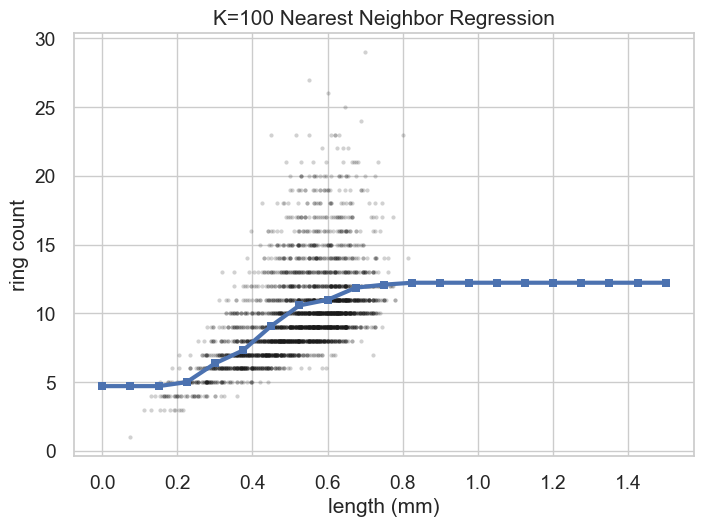

In [207]:
plt.plot(xlength_N1, y_N1, 'k.', alpha=0.2)
plt.plot(x_grid_G1, yhat_k100_G1, 'bs-', linewidth=3);
plt.xlabel('length (mm)'); plt.ylabel('ring count');
plt.title('K=100 Nearest Neighbor Regression');

# Exercises for Part 3

### Discussion Question 3(ii): k-NN should have a piecewise constant predictions.... why do the plots above look different?

*Hint:* Try a finer grid

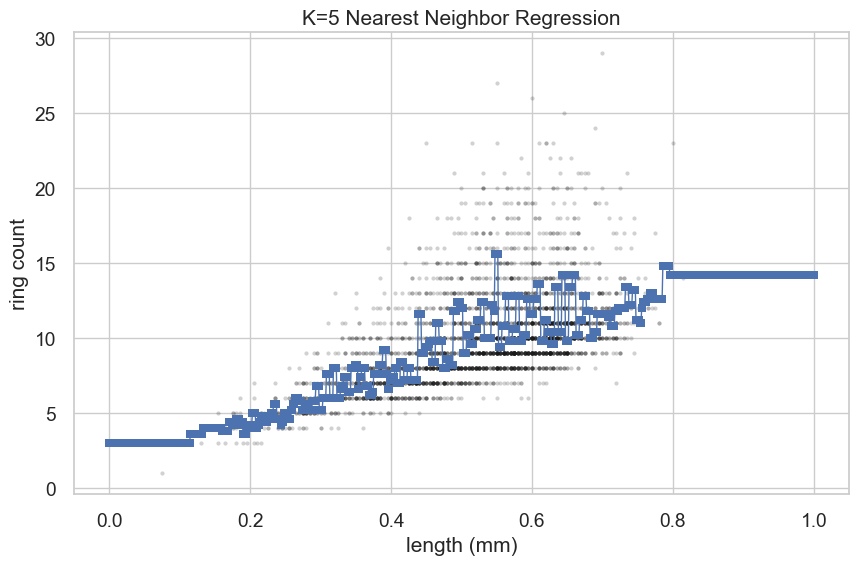

In [208]:
G = 1000
x_grid_G1000 = np.linspace(0, 1, G)
x_grid_G1000 = np.reshape(x_grid_G1000, (G, 1))

yhat_k5nn_G1000 = k5nn_regr.predict(x_grid_G1000)

plt.figure(figsize=(10, 6))
plt.plot(xlength_N1, y_N1, 'k.', alpha=0.2)
plt.plot(x_grid_G1000, yhat_k5nn_G1000, 'bs-', linewidth=1);
plt.xlabel('length (mm)'); plt.ylabel('ring count');
plt.title('K=5 Nearest Neighbor Regression');

### Exercise 3a (code): Make a plot of the mean squared error on the *training* set as a function of the number of neighbors

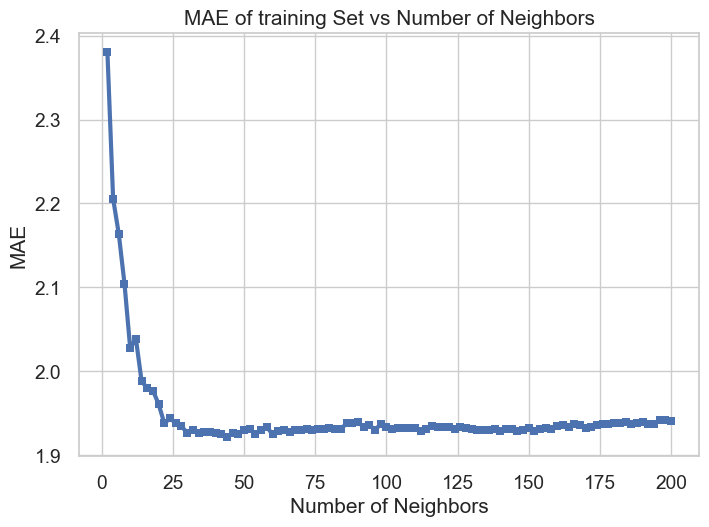

In [209]:
K = 100
step = 2
mae_vals = np.zeros((K))

for idx in range(K):
    knn_regr = sklearn.neighbors.KNeighborsRegressor(
        n_neighbors=(idx + 1) * step, algorithm = 'brute', metric='euclidean'
    )
    knn_regr.fit(xlength_N1, y_N1)
    y_hat_train = knn_regr.predict(xlength_N1)
    mae = sklearn.metrics.mean_absolute_error(y_N1, y_hat_train)
    mae_vals[idx] = mae

k_vals = np.arange(step, K * step + step, step)

plt.plot(k_vals, mae_vals, 'bs-', linewidth=3)
plt.xlabel('Number of Neighbors'); plt.ylabel('MAE');
plt.title('MAE of training Set vs Number of Neighbors');


# Challenge Yourself

### Exercise 3c (code): Can you write a function to reproduce what happens when you call `predict()` with kNN?

In [230]:
def my_knn_predict(X, y, query, K):
        Q, _ = query.shape

        predictions = np.zeros((Q, 1))

        for idx, q in enumerate(query):
                diff = X - q[np.newaxis, :]
                euc_dist_sq = np.sum(diff ** 2, axis = -1)

                # sklearn breaks ties by using the original sort order of data, which stable sort does
                # default for argsort is quicksort, which is unstable
                # but tie breaking issues still sem to persist
                ids = np.argsort(euc_dist_sq, kind='stable')[:K]
                pred = y[ids].mean()
                predictions[idx] = pred

        return predictions


knn_regr2 = sklearn.neighbors.KNeighborsRegressor(
        n_neighbors=5, algorithm = 'brute', metric='euclidean'
)
knn_regr2.fit(xlength_N1, y_N1)
y_hat_train = knn_regr2.predict(xlength_N1)
print("sklearn knn predictions:")
print(y_hat_train[:5])

my_y_hat_train = my_knn_predict(xlength_N1, y_N1, xlength_N1, 5)
print("\nmy knn predictions:")
print(my_y_hat_train[:5])

print("\nMAEs:")
print("Sklearn's:")
print(sklearn.metrics.mean_absolute_error(my_y_hat_train, y_N1))
print("Mine:")
print(sklearn.metrics.mean_absolute_error(y_hat_train, y_N1))


sklearn knn predictions:
[[ 7.2]
 [10.6]
 [ 9.8]
 [ 8.6]
 [11.6]]

my knn predictions:
[[ 7.2]
 [10.6]
 [ 9.8]
 [ 8.6]
 [14.8]]

MAEs:
Sklearn's:
2.1982367758186396
Mine:
2.1988664987405544
